# Industrial Defect Intelligence
### Steel surface defects: data quality and exploration

Steel surface defects vary in texture, shape and intensity. This project investigates whether those differences can support reliable classification across six defect categories in the NEU dataset.

**Research question:** How accurately can machine learning distinguish the six defect types, and which visual similarities make them difficult to separate?

This notebook establishes the data baseline: file integrity, class coverage, duplicate images and the distribution of basic image measurements. Model development follows once the data has passed acceptance checks.

### Running the notebook

The working directory is the project root, with images under `data/NEU-CLS`. Run the cells in order, or use **Restart Kernel and Run All Cells**. Figures are written to `outputs/figures` and audit tables to `outputs/reports`; both directories are created automatically.

Requirements: Python, Jupyter, NumPy, pandas, Matplotlib and Pillow. The analysis packages can be installed in the notebook's Python environment with:

```text
python -m pip install numpy pandas matplotlib Pillow
```


## 1. Setup

A fixed seed controls image sampling. Files are processed in sorted order, and each run records the Python and package versions alongside a SHA-256 manifest. Output files are replaced on subsequent runs; source images are left unchanged.


In [1]:
from pathlib import Path
from collections import Counter
from datetime import datetime, timezone
from importlib import metadata
import hashlib
import json
import platform
import random
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image, ImageFile

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
ImageFile.LOAD_TRUNCATED_IMAGES = False
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False, 'savefig.bbox': 'tight'})
RUN_UTC = datetime.now(timezone.utc).isoformat()


In [2]:
PROJECT_ROOT = Path.cwd().resolve()
DATASET_DIR = PROJECT_ROOT / 'data' / 'NEU-CLS'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
REPORTS_DIR = PROJECT_ROOT / 'outputs' / 'reports'
for directory in (FIGURES_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

environment = {
    'run_utc': RUN_UTC, 'seed': SEED, 'python': sys.version,
    'platform': platform.platform(), 'python_executable': sys.executable,
    'working_directory': str(PROJECT_ROOT),
    'packages': {name: metadata.version(name)
                 for name in ['numpy', 'pandas', 'matplotlib', 'Pillow']},
}
print(json.dumps(environment, indent=2))
(REPORTS_DIR / 'environment.json').write_text(json.dumps(environment, indent=2), encoding='utf-8')
print('Dataset folder exists:', DATASET_DIR.is_dir())
print('Figures will be saved to:', FIGURES_DIR)


{
  "run_utc": "2026-09-23T22:22:32.926483+00:00",
  "seed": 42,
  "python": "3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]",
  "platform": "Windows-11-10.0.26200-SP0",
  "python_executable": "C:\\Scripts\\industrial-defect-intelligence\\venv\\Scripts\\python.exe",
  "working_directory": "C:\\Scripts\\industrial-defect-intelligence",
  "packages": {
    "numpy": "2.5.3",
    "pandas": "3.0.6",
    "matplotlib": "3.11.2",
    "Pillow": "12.3.0"
  }
}
Dataset folder exists: True
Figures will be saved to: C:\Scripts\industrial-defect-intelligence\outputs\figures


## 2. Data source and licence

The [Northeastern University surface defect database](https://faculty.neu.edu.cn/songkc/en/zdylm/263265/list/) is credited to Kechen Song and Yunhui Yan. Its image-only classification collection, NEU-CLS, contains 1,800 greyscale images at 200 × 200 pixels, with 300 examples of each defect:

| Category | Label used in this project |
| --- | --- |
| Crazing | `crazing` |
| Inclusion | `inclusion` |
| Patches | `patches` |
| Pitted surface | `pitted_surface` |
| Rolled-in scale | `rolled_in_scale` |
| Scratches | `scratches` |

The collection contains defect images only, with no defect-free category. The original source distinguishes NEU-CLS from NEU-DET, which includes detection annotations.

The [Figshare distribution](https://figshare.com/articles/dataset/NEU-CLS/28903550), posted by Weilin Cao on 30 April 2025, lists [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). This record describes the distributed copy; the original dataset attribution remains with the Northeastern University researchers. Reuse requires attribution, a licence link and an indication of any changes.

The link between the local files and this distribution is pending verification. Annotation files or existing split folders may indicate repackaging. Local image hashes record the content analysed but do not establish its origin.

| Local source record | Status |
| --- | --- |
| Downloaded archive filename | Not recorded |
| Download date | Not recorded |
| Record version or DOI | Not recorded |
| Original archive SHA-256 | Not recorded |
| Repackaging history | Not verified |

`PROVENANCE_CONFIRMED` remains false until the local source record is documented and verified.


In [3]:
# Local source verification status; see the source record above.
PROVENANCE_CONFIRMED = False

EXPECTED_CLASSES = ['crazing', 'inclusion', 'patches', 'pitted_surface',
                    'rolled_in_scale', 'scratches']
EXPECTED_IMAGES = 1800
EXPECTED_PER_CLASS = 300
EXPECTED_SIZE = (200, 200)
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.pgm', '.webp'}

def sha256_file(path):
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


## 3. File discovery and labels

The recursive search supports class folders, flat image folders and nested split folders. Class names come from recognised folder names or filename prefixes such as `Cr_1.bmp` and `crazing_10.jpg`. Unknown labels and conflicting evidence are retained as audit failures.

Existing split folders are combined for the inventory. Non-image files are listed separately, and annotation files are not used to infer labels. The image manifest records the evidence behind each inferred class.


In [4]:
ALIASES = {
    'cr': 'crazing', 'crazing': 'crazing',
    'in': 'inclusion', 'inclusion': 'inclusion', 'inclusions': 'inclusion',
    'pa': 'patches', 'patch': 'patches', 'patches': 'patches',
    'ps': 'pitted_surface', 'pittedsurface': 'pitted_surface',
    'rs': 'rolled_in_scale', 'rolledinscale': 'rolled_in_scale',
    'sc': 'scratches', 'scratch': 'scratches', 'scratches': 'scratches',
}
def normalise(text):
    return re.sub(r'[^a-z]', '', text.lower())

def infer_label(path):
    relative = path.relative_to(DATASET_DIR)
    folder_labels = {ALIASES[normalise(part)] for part in relative.parts[:-1]
                     if normalise(part) in ALIASES}
    prefix = re.sub(r'[\s_-]*\d+.*$', '', path.stem)
    filename_label = ALIASES.get(normalise(prefix))
    candidates = folder_labels | ({filename_label} if filename_label else set())
    evidence = f'folders={sorted(folder_labels)}; filename={filename_label}'
    if len(candidates) > 1:
        return 'CONFLICT', evidence
    return (next(iter(candidates)) if candidates else 'UNKNOWN'), evidence

all_files = sorted((p for p in DATASET_DIR.rglob('*') if p.is_file()),
                   key=lambda p: p.relative_to(DATASET_DIR).as_posix()) if DATASET_DIR.is_dir() else []
image_files = [p for p in all_files if p.suffix.lower() in IMAGE_EXTENSIONS]
other_files = [p for p in all_files if p.suffix.lower() not in IMAGE_EXTENSIONS]
other_table = pd.DataFrame([{'path': p.relative_to(DATASET_DIR).as_posix(),
                            'extension': p.suffix.lower() or '(none)'} for p in other_files],
                          columns=['path', 'extension'])
other_table.to_csv(REPORTS_DIR / 'non_image_files.csv', index=False)
print(f'Image candidates: {len(image_files):,}; other files: {len(other_files):,}')
print('Image extensions:', dict(Counter(p.suffix.lower() for p in image_files)))
print('Other extensions:', dict(Counter(other_table['extension'])))
print('First relative paths:')
for path in image_files[:8]:
    print(' ', path.relative_to(DATASET_DIR).as_posix(), infer_label(path))


Image candidates: 1,800; other files: 1,802
Image extensions: {'.jpg': 1800}
Other extensions: {'.cache': 2, '.txt': 1800}
First relative paths:
  train/train/images/crazing_10.jpg ('crazing', 'folders=[]; filename=crazing')
  train/train/images/crazing_100.jpg ('crazing', 'folders=[]; filename=crazing')
  train/train/images/crazing_101.jpg ('crazing', 'folders=[]; filename=crazing')
  train/train/images/crazing_102.jpg ('crazing', 'folders=[]; filename=crazing')
  train/train/images/crazing_103.jpg ('crazing', 'folders=[]; filename=crazing')
  train/train/images/crazing_104.jpg ('crazing', 'folders=[]; filename=crazing')
  train/train/images/crazing_105.jpg ('crazing', 'folders=[]; filename=crazing')
  train/train/images/crazing_106.jpg ('crazing', 'folders=[]; filename=crazing')


## 4. Image integrity and measurements

Each image is hashed, verified by Pillow and reopened for full decoding. Read failures are recorded without interrupting the audit. Dimensions and storage modes are measured before conversion. Equal red, green and blue channels indicate greyscale content, including images stored in RGB mode.

Three descriptive measurements use an 8-bit greyscale copy in memory:

| Measurement | Definition |
| --- | --- |
| Brightness | Mean pixel intensity, from 0 to 255 |
| Contrast | Population standard deviation of pixel intensity |
| Sharpness | Variance of the four-neighbour Laplacian over interior pixels |

The Laplacian is calculated as `up + down + left + right − 4 × centre`. Its variance responds to texture and noise as well as focus, so it is treated as a sharpness proxy rather than a calibrated blur measure. Source files are neither resized nor overwritten.


In [5]:
rows = []
for path in image_files:
    label, evidence = infer_label(path)
    row = dict(path=path.relative_to(DATASET_DIR).as_posix(), class_name=label,
               label_evidence=evidence, extension=path.suffix.lower(), sha256=None,
               pixel_sha256=None, hash_error='', error='', readable=False,
               width=np.nan, height=np.nan, mode=None, image_format=None,
               frames=np.nan, greyscale=False, brightness=np.nan,
               contrast=np.nan, sharpness=np.nan)
    try:
        row['sha256'] = sha256_file(path)
    except Exception as exc:
        row['hash_error'] = f'{type(exc).__name__}: {exc}'
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('error', Image.DecompressionBombWarning)
            with Image.open(path) as img:
                img.verify()
            with Image.open(path) as img:
                img.load()
                row.update(width=img.width, height=img.height, mode=img.mode,
                           image_format=img.format, frames=getattr(img, 'n_frames', 1))
                rgb = np.asarray(img.convert('RGB'))
                row['greyscale'] = bool(np.array_equal(rgb[..., 0], rgb[..., 1]) and
                                        np.array_equal(rgb[..., 1], rgb[..., 2]))
                # Exact decoded RGB equality also finds different encodings of identical pixels.
                header = f'RGB:{img.width}:{img.height}:'.encode('ascii')
                row['pixel_sha256'] = hashlib.sha256(header + rgb.tobytes()).hexdigest()
                arr = np.asarray(img.convert('L'), dtype=np.float64)
                row['brightness'] = float(arr.mean())
                row['contrast'] = float(arr.std())
                if min(arr.shape) >= 3:
                    laplacian = (arr[:-2, 1:-1] + arr[2:, 1:-1] + arr[1:-1, :-2]
                                 + arr[1:-1, 2:] - 4 * arr[1:-1, 1:-1])
                    row['sharpness'] = float(laplacian.var())
                row['readable'] = True
    except Exception as exc:
        row['error'] = f'{type(exc).__name__}: {exc}'
    rows.append(row)

columns = ['path', 'class_name', 'label_evidence', 'extension', 'sha256',
           'pixel_sha256', 'hash_error', 'error', 'readable', 'width', 'height',
           'mode', 'image_format', 'frames', 'greyscale', 'brightness', 'contrast', 'sharpness']
audit = pd.DataFrame(rows, columns=columns)
readable = audit.loc[audit['readable'].eq(True)].copy()
bad_files = audit.loc[~audit['readable'].eq(True) | audit['hash_error'].ne('')]
class_counts = audit['class_name'].value_counts().reindex(EXPECTED_CLASSES, fill_value=0)
audit.to_csv(REPORTS_DIR / 'image_audit.csv', index=False)
bad_files.to_csv(REPORTS_DIR / 'unreadable_or_unhashable.csv', index=False)
print('Per-class counts (all candidates):\n', class_counts.to_string())
print('All inferred labels:\n', audit['class_name'].value_counts().to_string())
print('Dimensions (decoded images):\n', readable.groupby(['width', 'height']).size().to_string())
print('Image modes:\n', readable['mode'].value_counts().to_string())
print('Decoded formats:\n', readable['image_format'].value_counts().to_string())
print('Unreadable or unhashable files:', len(bad_files))
if len(bad_files):
    print(bad_files[['path', 'error', 'hash_error']].to_string(index=False))


Per-class counts (all candidates):
 class_name
crazing            300
inclusion          300
patches            300
pitted_surface     300
rolled_in_scale    300
scratches          300
All inferred labels:
 class_name
crazing            300
inclusion          300
patches            300
pitted_surface     300
rolled_in_scale    300
scratches          300
Dimensions (decoded images):
 width  height
200    200       1800
Image modes:
 mode
RGB    1800
Decoded formats:
 image_format
JPEG    1800
Unreadable or unhashable files: 0


## 5. Duplicate images

SHA-256 hashes identify duplicates at two levels: identical file bytes and identical decoded RGB pixels at the same dimensions. The pixel check can find matching images saved with different encodings. Neither check detects near-duplicates.

Duplicate groups are saved for review, including groups that span class labels. Unresolved duplicates fail acceptance because they could introduce leakage across a later training and evaluation split. The manifest fingerprint covers sorted relative paths and file hashes; it is separate from an archive checksum.


In [6]:
def duplicate_rows(table, key):
    valid = table.loc[table[key].notna()].copy()
    return valid.loc[valid.duplicated(key, keep=False)].sort_values([key, 'path'])

file_duplicates = duplicate_rows(audit, 'sha256')
pixel_duplicates = duplicate_rows(readable, 'pixel_sha256')
for name, frame, key in [('file_duplicates', file_duplicates, 'sha256'),
                         ('pixel_duplicates', pixel_duplicates, 'pixel_sha256')]:
    frame.to_csv(REPORTS_DIR / f'{name}.csv', index=False)
    print(f'{name}: {frame[key].nunique()} groups; {len(frame)} affected files')
    if len(frame):
        print(frame[['path', 'class_name', key]].to_string(index=False))

cross_label_groups = int((pixel_duplicates.groupby('pixel_sha256')['class_name'].nunique() > 1).sum())
manifest_text = ''.join(f"{r.path}\t{r.sha256 or 'HASH_ERROR'}\n" for r in audit.itertuples())
manifest_fingerprint = hashlib.sha256(manifest_text.encode('utf-8')).hexdigest()
(REPORTS_DIR / 'manifest_sha256.txt').write_text(manifest_fingerprint + '\n', encoding='utf-8')
print('Cross-label decoded-pixel duplicate groups:', cross_label_groups)
print('Local manifest SHA-256:', manifest_fingerprint)


file_duplicates: 1 groups; 2 affected files
                              path class_name                                                           sha256
train/train/images/patches_101.jpg    patches 4d2de82731b86cdbc7a66f2a9bfb01074bb4cb65e47bccf06b66470d53857071
train/train/images/patches_105.jpg    patches 4d2de82731b86cdbc7a66f2a9bfb01074bb4cb65e47bccf06b66470d53857071
pixel_duplicates: 1 groups; 2 affected files
                              path class_name                                                     pixel_sha256
train/train/images/patches_101.jpg    patches 0c8e6c64f970b25708f1ebf00872dea6153b9155ba7b505b2a65819eaa1a6192
train/train/images/patches_105.jpg    patches 0c8e6c64f970b25708f1ebf00872dea6153b9155ba7b505b2a65819eaa1a6192
Cross-label decoded-pixel duplicate groups: 0
Local manifest SHA-256: fad21284453048617a55f004d8e88babc61e8911f0193092fabb38727f977fdd


## 6. Image samples

Two readable images per class are selected with the fixed seed. A common 0–255 display scale preserves brightness differences between samples. Missing classes remain visible in the grid.


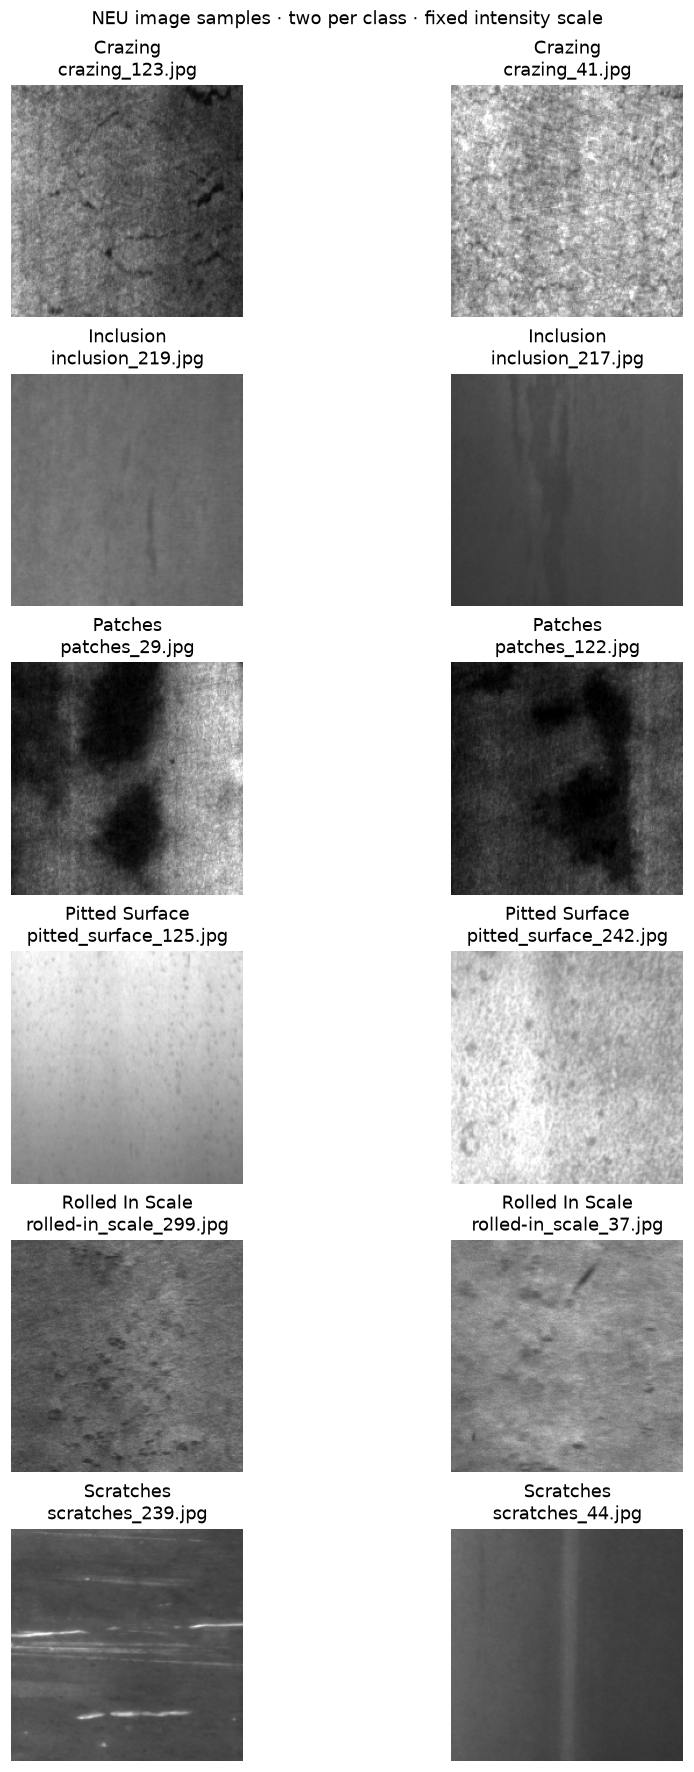

Saved: outputs\figures\01_class_samples.png


In [7]:
def save_figure(fig, filename):
    target = FIGURES_DIR / filename
    fig.savefig(target, dpi=160, facecolor='white')
    plt.show()
    plt.close(fig)
    print('Saved:', target.relative_to(PROJECT_ROOT))

rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(6, 2, figsize=(8, 16), squeeze=False, layout='constrained')
for row_index, class_name in enumerate(EXPECTED_CLASSES):
    candidates = readable.loc[readable['class_name'].eq(class_name), 'path'].tolist()
    selected = rng.choice(candidates, size=min(2, len(candidates)), replace=False).tolist()
    for column_index, ax in enumerate(axes[row_index]):
        ax.axis('off')
        if column_index < len(selected):
            relative_path = selected[column_index]
            with Image.open(DATASET_DIR / relative_path) as img:
                ax.imshow(np.asarray(img.convert('L')), cmap='gray', vmin=0, vmax=255)
            ax.set_title(f"{class_name.replace('_', ' ').title()}\n{Path(relative_path).name}")
        else:
            ax.text(0.5, 0.5, f'{class_name}\nNo readable sample', ha='center', va='center')
fig.suptitle('NEU image samples · two per class · fixed intensity scale')
save_figure(fig, '01_class_samples.png')


## 7. Class balance and image distributions

Class counts include all discovered image files. Brightness, contrast and sharpness distributions use readable images with recognised labels. Histograms show the collection as a whole; box plots show differences between classes.

These measurements describe both defect appearance and acquisition conditions. A difference between classes may therefore reflect lighting or surface finish as well as the defect itself.


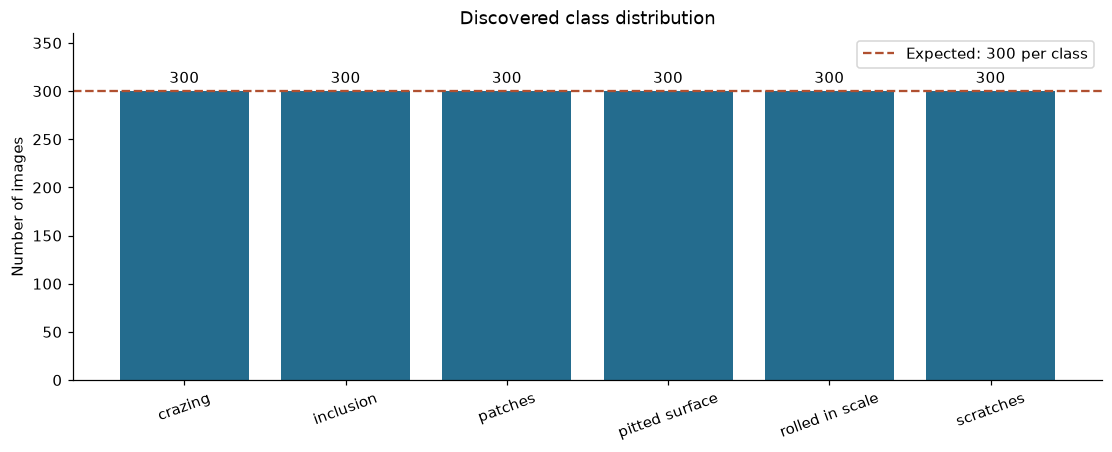

Saved: outputs\figures\02_class_distribution.png


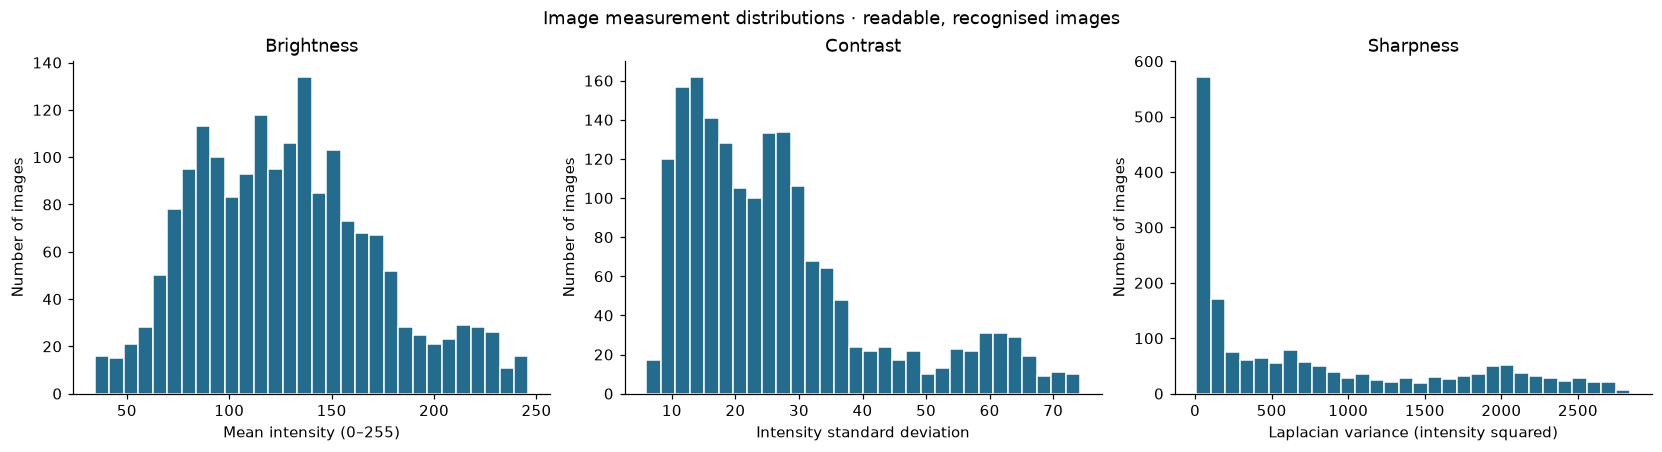

Saved: outputs\figures\03_measurement_distributions.png


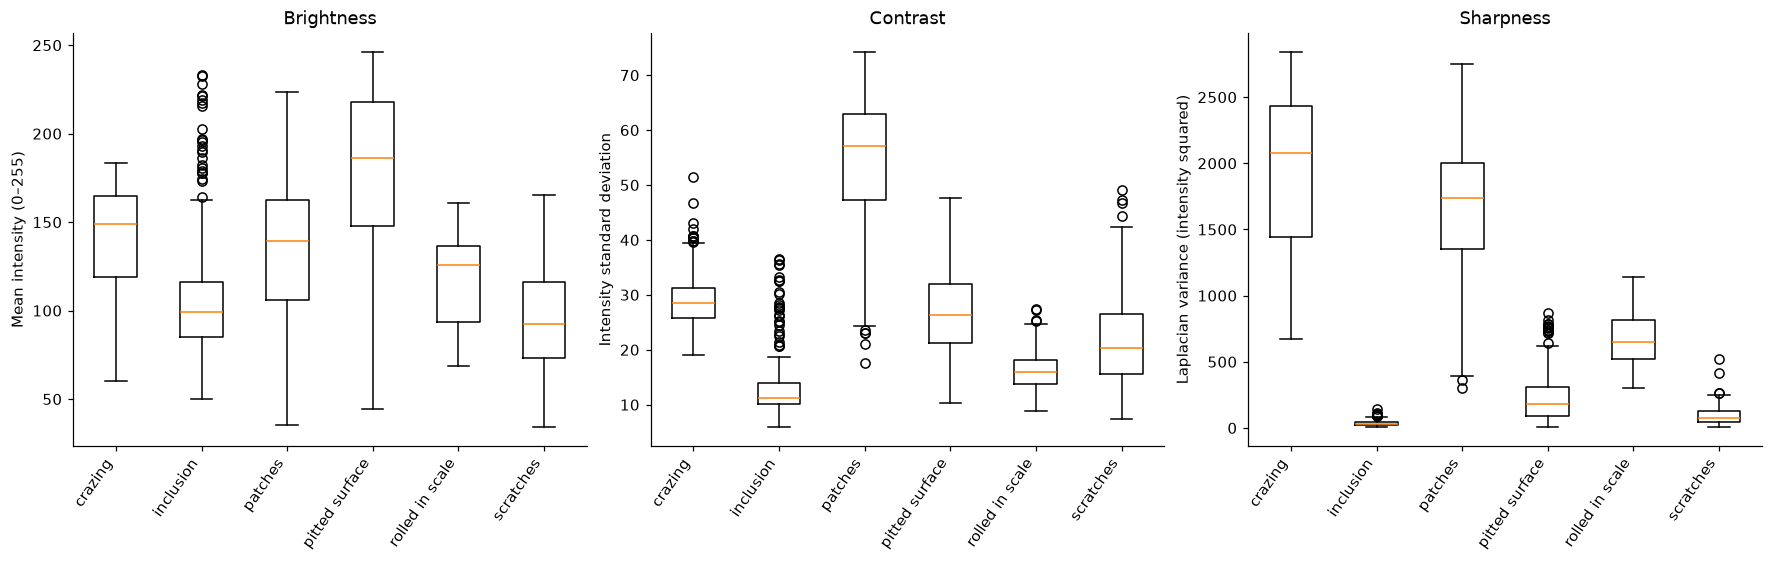

Saved: outputs\figures\04_measurements_by_class.png
                brightness                                       contrast                                    sharpness                                           
                     count    mean    std    min  median     max    count   mean    std    min median    max     count     mean     std     min   median      max
class_name                                                                                                                                                       
crazing                300  141.11  28.67  60.22  149.03  183.59      300  29.05   4.84  19.00  28.53  51.54       300  1962.78  552.01  670.72  2079.93  2840.71
inclusion              300  106.37  33.87  49.89   99.40  233.43      300  13.02   5.48   5.97  11.22  36.51       300    35.93   20.59    8.69    31.10   143.07
patches                300  132.51  43.06  35.57  139.12  223.67      300  54.22  12.31  17.56  57.09  74.21       300  1620.93  532.72  3

In [8]:
plot_counts = audit['class_name'].value_counts().reindex(
    EXPECTED_CLASSES + sorted(set(audit['class_name']) - set(EXPECTED_CLASSES)), fill_value=0)
fig, ax = plt.subplots(figsize=(10, 4), layout='constrained')
bars = ax.bar([s.replace('_', ' ') for s in plot_counts.index], plot_counts.values, color='#246c8e')
ax.axhline(EXPECTED_PER_CLASS, color='#b05030', linestyle='--', label='Expected: 300 per class')
ax.bar_label(bars, padding=3)
ax.set(ylabel='Number of images', title='Discovered class distribution')
ax.tick_params(axis='x', rotation=20)
ax.set_ylim(0, max(EXPECTED_PER_CLASS, int(plot_counts.max())) * 1.2)
ax.legend()
save_figure(fig, '02_class_distribution.png')

eda = readable.loc[readable['class_name'].isin(EXPECTED_CLASSES)].copy()
metrics = {'brightness': 'Mean intensity (0–255)',
           'contrast': 'Intensity standard deviation',
           'sharpness': 'Laplacian variance (intensity squared)'}
fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout='constrained')
for ax, (metric, label) in zip(axes, metrics.items()):
    values = eda[metric].dropna().astype(float)
    ax.hist(values, bins=30, color='#246c8e', edgecolor='white')
    ax.set(title=metric.title(), xlabel=label, ylabel='Number of images')
fig.suptitle('Image measurement distributions · readable, recognised images')
save_figure(fig, '03_measurement_distributions.png')

fig, axes = plt.subplots(1, 3, figsize=(16, 5), layout='constrained')
for ax, (metric, label) in zip(axes, metrics.items()):
    groups = [(name, eda.loc[eda['class_name'].eq(name), metric].dropna().astype(float).to_numpy())
              for name in EXPECTED_CLASSES]
    groups = [(name, values) for name, values in groups if len(values)]
    if groups:
        ax.boxplot([values for _, values in groups])
        ax.set_xticks(range(1, len(groups) + 1),
                      [name.replace('_', ' ') for name, _ in groups], rotation=55, ha='right')
    else:
        ax.text(0.5, 0.5, 'No valid measurements', ha='center', transform=ax.transAxes)
    ax.set(title=metric.title(), ylabel=label)
save_figure(fig, '04_measurements_by_class.png')

statistics = eda.groupby('class_name')[list(metrics)].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
statistics.to_csv(REPORTS_DIR / 'measurements_by_class.csv')
print(statistics.round(2).to_string())
print('Flat greyscale images (zero contrast):', int(eda['contrast'].eq(0).sum()))


## 8. Scope of the analysis

Balanced class counts do not establish label accuracy or independence between images. The sample grid provides an initial visual check, while the audit tables identify files that need closer inspection. Near-duplicate detection and a wider label review remain separate tasks.

Before model development, the source record and duplicate groups need to be resolved and an evaluation split defined. Related images should remain in the same partition. Exploration of the complete collection is descriptive; model comparisons require a reserved evaluation set.


## 9. Dataset acceptance

The summary applies the expected NEU-CLS specification: 1,800 readable images, six recognised classes, 300 images per class and 200 × 200 greyscale pixels.

| Result | Meaning |
| --- | --- |
| PASS | Check satisfied |
| WARN | Review or documentation required |
| FAIL | Critical acceptance check failed |

Exact duplicates fail acceptance until resolved. Storage-mode differences, extra files and incomplete provenance are reported for review. The results are saved to `outputs/reports/acceptance_summary.csv`.


In [9]:
findings = []
def check(name, passed, detail, failure='FAIL'):
    findings.append({'check': name, 'status': 'PASS' if bool(passed) else failure, 'detail': detail})

n = len(audit)
all_readable = n > 0 and len(readable) == n
check('Dataset folder', DATASET_DIR.is_dir(), str(DATASET_DIR))
check('Image count', n == EXPECTED_IMAGES, f'{n} found; expected {EXPECTED_IMAGES}')
observed_classes = set(audit['class_name'])
check('Six recognised classes', observed_classes == set(EXPECTED_CLASSES), str(sorted(observed_classes)))
check('Per-class counts', class_counts.eq(EXPECTED_PER_CLASS).all(), str(class_counts.to_dict()))
check('Unambiguous labels', n > 0 and audit['class_name'].isin(EXPECTED_CLASSES).all(),
      f"Unknown/conflicting labels: {int((~audit['class_name'].isin(EXPECTED_CLASSES)).sum())}")
check('All images readable', all_readable, f'{n - len(readable)} unreadable/corrupt files')
check('SHA-256 coverage', n > 0 and audit['sha256'].notna().all(),
      f"{audit['sha256'].notna().sum()} of {n} file hashes obtained")
check('200 × 200 dimensions', all_readable and readable['width'].eq(200).all() and readable['height'].eq(200).all(),
      str(readable.groupby(['width', 'height']).size().to_dict()))
check('Greyscale pixel content', all_readable and readable['greyscale'].eq(True).all(),
      f"{int(readable['greyscale'].eq(True).sum())} of {n} confirmed greyscale")
check('Native 8-bit greyscale mode', all_readable and readable['mode'].eq('L').all(),
      str(readable['mode'].value_counts().to_dict()), failure='WARN')
check('Single-frame images', all_readable and readable['frames'].eq(1).all(),
      'Multi-frame images require an explicit handling decision')
check('No byte-identical duplicates', file_duplicates.empty,
      f"{file_duplicates['sha256'].nunique()} duplicate groups")
check('No identical decoded pixels', pixel_duplicates.empty,
      f"{pixel_duplicates['pixel_sha256'].nunique()} groups; {cross_label_groups} span labels")
check('No flat images', all_readable and readable['contrast'].gt(0).all(),
      f"{int(readable['contrast'].eq(0).sum())} zero-contrast images", failure='WARN')
check('No extra files', not other_files,
      f'{len(other_files)} non-image files; inspect non_image_files.csv, especially annotations', failure='WARN')
check('Provenance and licence verified', PROVENANCE_CONFIRMED,
      'Local source record and correspondence to the cited release require verification', failure='WARN')

summary = pd.DataFrame(findings)
summary.to_csv(REPORTS_DIR / 'acceptance_summary.csv', index=False)
print(summary.to_string(index=False))
critical_pass = not summary['status'].eq('FAIL').any()
warning_count = int(summary['status'].eq('WARN').sum())
overall = 'FAIL' if not critical_pass else ('WARN' if warning_count else 'PASS')
print(f'\nOVERALL: {overall} | Critical checks: {"PASS" if critical_pass else "FAIL"} | Warnings: {warning_count}')
print('Modelling should not begin until critical checks pass.')
if not critical_pass:
    print('NOT ACCEPTED: investigate the failed checks and rerun the complete notebook.')
elif not PROVENANCE_CONFIRMED:
    print('PENDING: technical checks passed; verify provenance/licence and resolve or document warnings before modelling.')
elif warning_count:
    print('CONDITIONAL: critical checks passed; document warning resolutions before proceeding.')
else:
    print('ACCEPTED: dataset checks passed. Ready for split design and model development.')
print('Reports:', REPORTS_DIR)
print('Figures:', FIGURES_DIR)


                          check status                                                                                                              detail
                 Dataset folder   PASS                                                              C:\Scripts\industrial-defect-intelligence\data\NEU-CLS
                    Image count   PASS                                                                                           1800 found; expected 1800
         Six recognised classes   PASS                               ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled_in_scale', 'scratches']
               Per-class counts   PASS {'crazing': 300, 'inclusion': 300, 'patches': 300, 'pitted_surface': 300, 'rolled_in_scale': 300, 'scratches': 300}
             Unambiguous labels   PASS                                                                                       Unknown/conflicting labels: 0
            All images readable   PASS                                